In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches
import torch_geometric
from torch.utils.data import Dataset, DataLoader


In [20]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.01, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx = 500
dt0 = 1e-4
nu = 0.01
n_steps = 20000   # match MLP experiment

x, data = generate_diffusion_data(Nx, nu, dt0, n_steps)



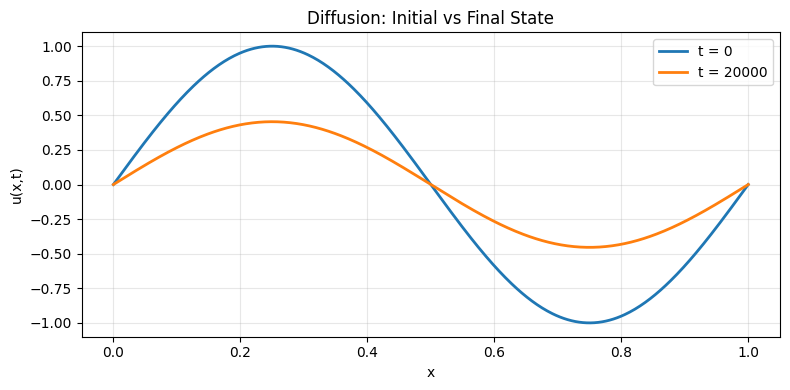

In [21]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
import torch
import numpy as np
from torch_geometric.data import Data


def sample_one_B_GNN(u, R=5, k=5, max_tries=50, u_scale=None):
    """
    Sample a single training example for a GNN-based PDE solver.
    
    Returns a torch_geometric.Data object containing:
        - pos: (k+1, 2) spatial coordinates of neighbors + center
        - x: (k+1, 1) field values at each point
        - edge_index: (2, k) edges from neighbors to center
        - center_idx: index of center node (=k)
        - target: scalar (normalized u at center)
    
    This format allows the GNN to:
    - Learn node embeddings from spatial position and field value
    - Pass messages from neighbors to center through edges
    - Predict the center node value
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for attempt in range(max_tries):
        # --- 1) Random center point ---
        t0 = np.random.randint(0, Nt)
        x0 = np.random.randint(0, Nx)

        # --- 2) Ellipse radii (in index space) ---
        Rt = R
        Rx = R

        # Bounding box
        t_min = max(0, int(t0 - Rt))
        t_max = min(Nt - 1, int(t0 + Rt))
        x_min = max(0, int(x0 - Rx))
        x_max = min(Nx - 1, int(x0 + Rx))

        # --- 3) Collect candidates within ellipse ---
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue

                dt = (t - t0) / Rt
                dx = (x - x0) / Rx

                if dt*dt + dx*dx <= 1.0:
                    cand.append((t, x))

        if len(cand) < k:
            continue  # Retry if insufficient neighbors

        # --- 4) Sample k neighbors ---
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neighbors = cand[idx]  # (k, 2)

        # --- 5) Build GNN graph ---
        # Nodes: [neighbor_0, neighbor_1, ..., neighbor_{k-1}, center]
        all_points = np.vstack([neighbors, [[t0, x0]]])  # (k+1, 2)
        center_idx = k
        
        # Normalize spatial coordinates to [-1, 1] range relative to domain
        pos = all_points.astype(np.float32)
        pos[:, 0] = 2 * pos[:, 0] / Nt - 1  # time coordinate
        pos[:, 1] = 2 * pos[:, 1] / Nx - 1  # space coordinate

        # Node features: field values
        x = np.zeros((k + 1, 1), dtype=np.float32)
        for i in range(k):
            t, x_coord = neighbors[i]
            x[i, 0] = u[t, x_coord] / u_scale
        x[center_idx, 0] = u[t0, x0] / u_scale

        # Edge index: edges from all neighbors to center
        # Format: [source_nodes, target_nodes]
        edge_index = np.zeros((2, k), dtype=np.int64)
        edge_index[0, :] = np.arange(k)      # source: neighbors 0..k-1
        edge_index[1, :] = center_idx         # target: center node

        # Target value (what we're predicting)
        target = np.float32(u[t0, x0] / u_scale)

        # Convert to torch and create Data object
        data = Data(
            pos=torch.from_numpy(pos),
            x=torch.from_numpy(x),
            edge_index=torch.from_numpy(edge_index),
            center_idx=center_idx,
            target=torch.tensor(target, dtype=torch.float32)
        )

        return data

    raise RuntimeError("Failed to sample B-example; try increasing R or k.")


def sample_batch_B_GNN(u, batch_size=32, R=5, k=5, u_scale=None):
    """
    Sample a batch of training examples.
    
    Returns:
        list of torch_geometric.Data objects
    """
    batch = []
    for _ in range(batch_size):
        data = sample_one_B_GNN(u, R=R, k=k, u_scale=u_scale)
        batch.append(data)
    return batch

In [23]:
import torch
import numpy as np
from torch_geometric.data import Data


def sample_one_B_GNN(u, R=5, k=5, max_tries=50, u_scale=None):
    """
    Sample a single training example for a GNN-based PDE solver.
    
    Returns a torch_geometric.Data object containing:
        - pos: (k+1, 2) spatial coordinates of neighbors + center
        - x: (k+1, 1) field values at each point
        - edge_index: (2, k) edges from neighbors to center
        - center_idx: index of center node (=k)
        - target: scalar (normalized u at center)
    
    This format allows the GNN to:
    - Learn node embeddings from spatial position and field value
    - Pass messages from neighbors to center through edges
    - Predict the center node value
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for attempt in range(max_tries):
        # --- 1) Random center point ---
        t0 = np.random.randint(0, Nt)
        x0 = np.random.randint(0, Nx)

        # --- 2) Ellipse radii (in index space) ---
        Rt = R
        Rx = R

        # Bounding box
        t_min = max(0, int(t0 - Rt))
        t_max = min(Nt - 1, int(t0 + Rt))
        x_min = max(0, int(x0 - Rx))
        x_max = min(Nx - 1, int(x0 + Rx))

        # --- 3) Collect candidates within ellipse ---
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue

                dt = (t - t0) / Rt
                dx = (x - x0) / Rx

                if dt*dt + dx*dx <= 1.0:
                    cand.append((t, x))

        if len(cand) < k:
            continue  # Retry if insufficient neighbors

        # --- 4) Sample k neighbors ---
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neighbors = cand[idx]  # (k, 2)

        # --- 5) Build GNN graph ---
        # Nodes: [neighbor_0, neighbor_1, ..., neighbor_{k-1}, center]
        all_points = np.vstack([neighbors, [[t0, x0]]])  # (k+1, 2)
        center_idx = k
        
        # Normalize spatial coordinates to [-1, 1] range relative to domain
        pos = all_points.astype(np.float32)
        pos[:, 0] = 2 * pos[:, 0] / Nt - 1  # time coordinate
        pos[:, 1] = 2 * pos[:, 1] / Nx - 1  # space coordinate

        # Node features: field values
        x = np.zeros((k + 1, 1), dtype=np.float32)
        for i in range(k):
            t, x_coord = neighbors[i]
            x[i, 0] = u[t, x_coord] / u_scale
        x[center_idx, 0] = u[t0, x0] / u_scale

        # Edge index: edges from all neighbors to center
        # Format: [source_nodes, target_nodes]
        edge_index = np.zeros((2, k), dtype=np.int64)
        edge_index[0, :] = np.arange(k)      # source: neighbors 0..k-1
        edge_index[1, :] = center_idx         # target: center node

        # Target value (what we're predicting)
        target = np.float32(u[t0, x0] / u_scale)

        # Convert to torch and create Data object
        data = Data(
            pos=torch.from_numpy(pos),
            x=torch.from_numpy(x),
            edge_index=torch.from_numpy(edge_index),
            center_idx=center_idx,
            target=torch.tensor(target, dtype=torch.float32)
        )

        return data

    raise RuntimeError("Failed to sample B-example; try increasing R or k.")


def sample_batch_B_GNN(u, batch_size=32, R=5, k=5, u_scale=None):
    """
    Sample a batch of training examples.
    
    Returns:
        list of torch_geometric.Data objects
    """
    batch = []
    for _ in range(batch_size):
        data = sample_one_B_GNN(u, R=R, k=k, u_scale=u_scale)
        batch.append(data)
    return batch

In [24]:
import torch
import torch.nn as nn
from torch_geometric.data import DataLoader, Dataset
from torch_geometric.nn import GCNConv
import time


class BDatasetGNN(Dataset):
    """
    Dataset that generates k-NN graph samples on-the-fly or precomputed.
    """
    def __init__(self, u, N_samples=100000, R=5, k=5, pregenerate=True):
        super().__init__()
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.pregenerate = pregenerate
        self.u_scale = max(1e-8, np.max(np.abs(u)))
        
        if pregenerate:
            print(f"Pregenerating {N_samples} samples...")
            self.samples = [sample_one_B_GNN(u, R=R, k=k, u_scale=self.u_scale) 
                           for _ in range(N_samples)]
            print(f"Generated {len(self.samples)} samples")
        else:
            self.samples = None
    
    def len(self):
        return self.N_samples
    
    def get(self, idx):
        if self.pregenerate:
            return self.samples[idx]
        else:
            return sample_one_B_GNN(self.u, R=self.R, k=self.k, u_scale=self.u_scale)


class GNNIntegratorGNN(nn.Module):
    """
    GNN-based integrator for local PDE solving.
    
    Architecture:
    - Encode node features (position + field value)
    - Message passing: neighbors → center
    - Decode: predict center value from aggregated messages
    """
    
    def __init__(self, hidden=128, num_layers=3, dropout=0.0):
        super().__init__()
        self.hidden = hidden
        self.num_layers = num_layers
        
        # Node encoder: (pos_dim + feature_dim) → hidden
        # pos: (x, y) in [-1, 1], x: field value (1 dim)
        self.node_encoder = nn.Sequential(
            nn.Linear(2 + 1, hidden),  # 2D position + 1D field value
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        
        # Message passing layers (GCN)
        self.gnn_layers = nn.ModuleList([
            GCNConv(hidden, hidden)
            for _ in range(num_layers)
        ])
        
        self.dropout = nn.Dropout(dropout)
        
        # Decoder: predict center node value from its embedding
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    
    def forward(self, data):
        """
        Forward pass on batched graph data.
        
        Args:
            data: torch_geometric.data.Batch object containing:
                - pos: (N, 2) node positions
                - x: (N, 1) node field values
                - edge_index: (2, E) edge indices
                - center_idx: center node indices (for each graph in batch)
                - batch: (N,) graph assignment indices
        
        Returns:
            predictions: (batch_size,) predicted center values
        """
        pos = data.pos
        x = data.x
        edge_index = data.edge_index
        batch = data.batch  # which graph each node belongs to
        
        # Combine position and field value as node features
        node_feats = torch.cat([pos, x], dim=1)  # (N, 3)
        
        # Encode nodes
        h = self.node_encoder(node_feats)  # (N, hidden)
        
        # Message passing
        for gnn_layer in self.gnn_layers:
            h = gnn_layer(h, edge_index)
            h = torch.relu(h)
            h = self.dropout(h)
        
        # Extract center node embeddings for each graph in batch
        # Center nodes are at index k in each graph (last node of k+1 nodes)
        center_indices = data.center_idx  # (batch_size,)
        
        # Adjust indices for batched data
        graph_ids = batch[center_indices]
        batch_offsets = torch.zeros(batch.max().item() + 1, device=batch.device, dtype=torch.long)
        batch_offsets[1:] = torch.cumsum(
            torch.bincount(batch, minlength=batch.max().item() + 1)[:-1], dim=0
        )
        adjusted_center_indices = center_indices + batch_offsets[graph_ids]
        
        center_embeddings = h[adjusted_center_indices]  # (batch_size, hidden)
        
        # Decode to predictions
        predictions = self.decoder(center_embeddings).squeeze(-1)  # (batch_size,)
        
        return predictions


def train_integrator_B_gnn(
    u, epochs=50, batch_size=32, k=5, R=5,
    N_samples=100000, lr=1e-3, hidden=128, num_layers=3,
    device="cuda", use_amp=True, pregenerate=True
):
    """
    Train GNN integrator with same experimental setup as MLP pipeline.
    
    Args:
        u: (Nt, Nx) solution field
        epochs: number of training epochs
        batch_size: number of graphs per batch
        k: number of neighbors per graph
        R: neighborhood radius
        N_samples: total training samples to generate
        lr: learning rate
        hidden: hidden dimension
        num_layers: number of GNN layers
        device: "cuda" or "cpu"
        use_amp: whether to use mixed precision
        pregenerate: precompute all samples vs generate on-the-fly
    
    Returns:
        model: trained GNN model
        dataset: dataset object
    """
    
    device = torch.device(device)
    
    print("Setting up dataset...")
    dataset = BDatasetGNN(u, N_samples=N_samples, R=R, k=k, pregenerate=pregenerate)
    
    # torch_geometric DataLoader handles batching of graphs
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,  # GNN Data objects don't parallelize well
        pin_memory=True
    )
    
    model = GNNIntegratorGNN(hidden=hidden, num_layers=num_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5, verbose=True
    )
    loss_fn = nn.MSELoss()
    
    if use_amp and device.type == "cuda":
        scaler = torch.cuda.amp.GradScaler()
    else:
        scaler = None
    
    print(f"Training on device: {device}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Samples: {N_samples:,}, batch={batch_size}, graphs/batch")
    print(f"Hidden: {hidden}, Layers: {num_layers}")
    print(f"Mixed precision: {use_amp}\n")
    
    # Warmup batch
    if device.type == 'cuda':
        model.train()
        warm_batch = next(iter(loader))
        warm_batch = warm_batch.to(device)
        print("GPU warmup...")
        for _ in range(3):
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(warm_batch)
                loss = loss_fn(pred, warm_batch.target)
            loss.backward()
            opt.step()
        torch.cuda.synchronize()
        print("Warmup complete.\n")
    
    total_batches = len(loader)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_samples = 0
        start = time.time()
        
        for batch_idx, batch in enumerate(loader):
            batch = batch.to(device, non_blocking=True)
            
            opt.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    pred = model(batch)
                    loss = loss_fn(pred, batch.target)
                scaler.scale(loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
            else:
                pred = model(batch)
                loss = loss_fn(pred, batch.target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            
            batch_size_actual = batch.num_graphs
            total_loss += loss.item() * batch_size_actual
            num_samples += batch_size_actual
        
        avg_loss = total_loss / num_samples
        scheduler.step(avg_loss)
        lr_now = opt.param_groups[0]['lr']
        dur = time.time() - start
        
        print(f"[Epoch {epoch+1:3d}/{epochs}] loss={avg_loss:.6e}, lr={lr_now:.2e}, time={dur:.1f}s")
    
    return model.to(device), dataset

In [25]:
import torch
import torch.nn as nn
from torch_geometric.data import DataLoader


def eval_integrator_B_gnn(
    model,
    dataset,
    N_test=10000,
    batch_size=32,
    device="cuda",
    use_amp=True
):
    """
    Evaluate GNN integrator on test set.
    
    Args:
        model: trained GNNIntegratorGNN model
        dataset: BDatasetGNN instance (contains u, R, k, u_scale)
        N_test: number of test samples to generate
        batch_size: number of graphs per batch
        device: "cuda" or "cpu"
        use_amp: whether to use mixed precision
    
    Returns:
        avg_loss: average MSE loss on test set
    """
    device = torch.device(device)
    model.eval()

    # Generate fresh test dataset with different random seed
    print(f"Generating {N_test} test samples...")
    test_ds = BDatasetGNN(
        dataset.u,
        N_samples=N_test,
        R=dataset.R,
        k=dataset.k,
        pregenerate=True  # precompute for speed
    )
    print(f"Test dataset ready: {N_test} graphs")

    # torch_geometric DataLoader batches graphs
    loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    loss_fn = nn.MSELoss()
    total_loss = 0.0
    num_graphs = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device, non_blocking=True)

            if use_amp and device.type == 'cuda':
                with torch.cuda.amp.autocast():
                    pred = model(batch)
                    loss = loss_fn(pred, batch.target)
            else:
                pred = model(batch)
                loss = loss_fn(pred, batch.target)

            batch_size_actual = batch.num_graphs
            total_loss += loss.item() * batch_size_actual
            num_graphs += batch_size_actual

    avg_loss = total_loss / num_graphs
    print(f"[Eval GNN] MSE = {avg_loss:.6e} over {num_graphs} graphs\n")
    return avg_loss

In [26]:
# Train GNN-based PDE integrator
model, train_ds = train_integrator_B_gnn(
    data,
    epochs=100,
    batch_size=32,           # Now: graphs per batch (not samples)
                             # 32 graphs * 6 nodes = 192 nodes ~equivalent to original
    k=5,                     # 5 neighbors per center
    R=5,                     # neighborhood radius
    N_samples=10000,        # total graphs to generate
    lr=1e-3,
    hidden=512,              # GNN hidden dimension
    num_layers=3,            # GNN message passing layers
    device="cuda",
    use_amp=True,
    pregenerate=True         # precompute all samples upfront
)

# Optional: evaluate on test set
test_loss = eval_integrator_B_gnn(
    model,
    train_ds,
    N_test=1000,
    batch_size=32,
    device="cuda",
    use_amp=True
)

Setting up dataset...
Pregenerating 10000 samples...
Generated 10000 samples
Training on device: cuda
Parameters: 1,315,841
Samples: 10,000, batch=32, graphs/batch
Hidden: 512, Layers: 3
Mixed precision: True

GPU warmup...
Warmup complete.



C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\1826020103.py:164: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(
C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\1826020103.py:180: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\1826020103.py:198: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\1826020103.py:220: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[Epoch   1/100] loss=2.563881e-01, lr=1.00e-03, time=1.8s
[Epoch   2/100] loss=2.502836e-01, lr=1.00e-03, time=1.7s
[Epoch   3/100] loss=2.485210e-01, lr=1.00e-03, time=1.8s
[Epoch   4/100] loss=2.485229e-01, lr=1.00e-03, time=1.8s
[Epoch   5/100] loss=2.484508e-01, lr=1.00e-03, time=1.9s
[Epoch   6/100] loss=2.484874e-01, lr=1.00e-03, time=1.7s
[Epoch   7/100] loss=2.484678e-01, lr=1.00e-03, time=1.7s
[Epoch   8/100] loss=2.484479e-01, lr=1.00e-03, time=1.8s
[Epoch   9/100] loss=2.484127e-01, lr=1.00e-03, time=1.8s
[Epoch  10/100] loss=2.483980e-01, lr=1.00e-03, time=1.9s
[Epoch  11/100] loss=2.483507e-01, lr=1.00e-03, time=1.9s
[Epoch  12/100] loss=2.483078e-01, lr=1.00e-03, time=2.0s
[Epoch  13/100] loss=2.482791e-01, lr=1.00e-03, time=1.8s
[Epoch  14/100] loss=2.482508e-01, lr=1.00e-03, time=1.9s
[Epoch  15/100] loss=2.482132e-01, lr=1.00e-03, time=1.6s
[Epoch  16/100] loss=2.481940e-01, lr=1.00e-03, time=1.7s
[Epoch  17/100] loss=2.481453e-01, lr=1.00e-03, time=1.7s
[Epoch  18/100

C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\787181386.py:43: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(
C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\787181386.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [ ]:
import torch

# ============================================================================
# SAVE
# ============================================================================

model_save_path = "model_integrator_gnn2.pth"

checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_type': 'gnn',
    'arch_version': 1,
    'k': train_ds.k,
    'R': train_ds.R,
    'hidden': model.hidden,
    'num_layers': model.num_layers,
    'u_scale': train_ds.u_scale,
    'Nx': data.shape[1],
    'Nt': data.shape[0],
}

torch.save(checkpoint, model_save_path)
print(f"GNN model saved to {model_save_path}")
print(f"  - Architecture: GNN with {model.num_layers} layers, {model.hidden} hidden dim")
print(f"  - k={train_ds.k}, R={train_ds.R}")
print(f"  - Domain: Nt={data.shape[0]}, Nx={data.shape[1]}")


# ============================================================================
# LOAD
# ============================================================================

def load_gnn_model(checkpoint_path, device="cuda"):
    """
    Load trained GNN integrator from checkpoint.
    
    Returns:
        model: GNNIntegratorGNN instance
        config: dict with model hyperparameters
    """
    device = torch.device(device)
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    assert checkpoint['model_type'] == 'gnn', "Checkpoint is not a GNN model"
    
    config = {
        'k': checkpoint['k'],
        'R': checkpoint['R'],
        'hidden': checkpoint['hidden'],
        'num_layers': checkpoint['num_layers'],
        'u_scale': checkpoint['u_scale'],
        'Nx': checkpoint['Nx'],
        'Nt': checkpoint['Nt'],
    }
    
    # Reconstruct model
    model = GNNIntegratorGNN(
        hidden=config['hidden'],
        num_layers=config['num_layers'],
        dropout=0.0
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"Loaded GNN model from {checkpoint_path}")
    print(f"  - Architecture: {config['num_layers']} layers, {config['hidden']} hidden dim")
    print(f"  - k={config['k']}, R={config['R']}, u_scale={config['u_scale']:.4f}")
    print(f"  - Domain: Nt={config['Nt']}, Nx={config['Nx']}")
    
    return model, config


# Example usage:
# model, config = load_gnn_model("model_integrator_gnn.pth", device="cuda")

GNN model saved to model_integrator_gnn.pth
  - Architecture: GNN with 3 layers, 512 hidden dim
  - k=5, R=5
  - Domain: Nt=20001, Nx=500


In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data, Batch


def visualize_B_with_prediction_gnn(u, model, R=5, k=5, device="cuda"):
    """
    Visualize GNN prediction on a random Scheme-B neighborhood.
    
    Args:
        u: (Nt, Nx) solution field
        model: trained GNNIntegratorGNN
        R: neighborhood radius
        k: number of neighbors
        device: "cuda" or "cpu"
    """
    model.eval()
    device = torch.device(device)
    
    Nt, Nx = u.shape
    u_scale = np.max(np.abs(u)) + 1e-8

    # --- Sample random center point ---
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # --- Collect neighbors within ellipse (match Scheme-B) ---
    Rt = Rx = R
    t_min = max(0, int(t0 - Rt))
    t_max = min(Nt - 1, int(t0 + Rt))
    x_min = max(0, int(x0 - Rx))
    x_max = min(Nx - 1, int(x0 + Rx))

    cand = []
    for t in range(t_min, t_max + 1):
        for x in range(x_min, x_max + 1):
            if t == t0 and x == x0:
                continue
            
            dt = (t - t0) / Rt
            dx = (x - x0) / Rx
            
            if dt*dt + dx*dx <= 1.0:
                cand.append((t, x))

    cand = np.array(cand)
    assert len(cand) >= k, f"Not enough neighbors: {len(cand)} < {k}"

    # --- Sample k neighbors ---
    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]  # (k, 2)

    # --- Build GNN graph data ---
    # Nodes: [neighbor_0, ..., neighbor_{k-1}, center]
    all_points = np.vstack([neigh, [[t0, x0]]])  # (k+1, 2)
    center_idx = k
    
    # Normalize positions to [-1, 1]
    pos = all_points.astype(np.float32)
    pos[:, 0] = 2 * pos[:, 0] / Nt - 1
    pos[:, 1] = 2 * pos[:, 1] / Nx - 1
    
    # Node features: field values
    x = np.zeros((k + 1, 1), dtype=np.float32)
    for i in range(k):
        t, x_coord = neigh[i]
        x[i, 0] = u[t, x_coord] / u_scale
    x[center_idx, 0] = u[t0, x0] / u_scale
    
    # Edge index: neighbors → center
    edge_index = np.zeros((2, k), dtype=np.int64)
    edge_index[0, :] = np.arange(k)
    edge_index[1, :] = center_idx
    
    # Create Data object
    data = Data(
        pos=torch.from_numpy(pos),
        x=torch.from_numpy(x),
        edge_index=torch.from_numpy(edge_index),
        center_idx=center_idx,
        target=torch.tensor(u[t0, x0] / u_scale, dtype=torch.float32)
    )
    
    # Batch to match training format
    batch_data = Batch.from_data_list([data]).to(device)
    
    # --- Prediction ---
    with torch.no_grad():
        if device.type == 'cuda':
            with torch.cuda.amp.autocast():
                pred_normalized = model(batch_data)
        else:
            pred_normalized = model(batch_data)
        
        pred = pred_normalized.item() * u_scale
    
    true = u[t0, x0]
    err = pred - true
    pct = abs(err) / (abs(true) + 1e-8) * 100.0

    # --- Visualization ---
    fig, ax = plt.subplots(figsize=(6, 6))

    # Circle boundary
    circle = patches.Circle((x0, t0), radius=R, fill=False,
                            edgecolor='blue', linewidth=1.5, linestyle='--')
    ax.add_patch(circle)

    # Neighbor points
    ax.scatter(neigh[:, 1], neigh[:, 0], s=120, c='blue', 
               marker='o', zorder=3, label='Neighbors')
    
    # Lines from neighbors to center
    for (tn, xn) in neigh:
        ax.plot([x0, xn], [t0, tn], color='cyan', alpha=0.4, linewidth=0.8)

    # Center point
    ax.scatter([x0], [t0], c='red', s=250, marker='*', 
               zorder=4, label='Center (target)', edgecolors='darkred', linewidth=1)

    # Info text box
    textstr = (f"Ground truth:  {true:>10.6f}\n"
               f"Prediction:    {pred:>10.6f}\n"
               f"Error:         {err:>10.6f}\n"
               f"% Error:       {pct:>10.2f}%")
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            fontfamily='monospace', bbox=props)

    # Formatting
    pad = 2
    ax.set_xlim(x0 - R - pad, x0 + R + pad)
    ax.set_ylim(t0 + R + pad, t0 - R - pad)
    ax.set_aspect('equal')
    ax.set_xlabel("x (space index)", fontsize=11)
    ax.set_ylabel("t (time index, upward →)", fontsize=11)
    ax.set_title(f"GNN Prediction | k={k}, R={R}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'true': true,
        'pred': pred,
        'error': err,
        'percent_error': pct,
        'center': (t0, x0),
        'neighbors': neigh
    }


# Example usage:
# result = visualize_B_with_prediction_gnn(data, model, R=5, k=5, device="cuda")
# print(f"Prediction error: {result['percent_error']:.2f}%")

C:\Users\amt35\AppData\Local\Temp\ipykernel_29780\68114613.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


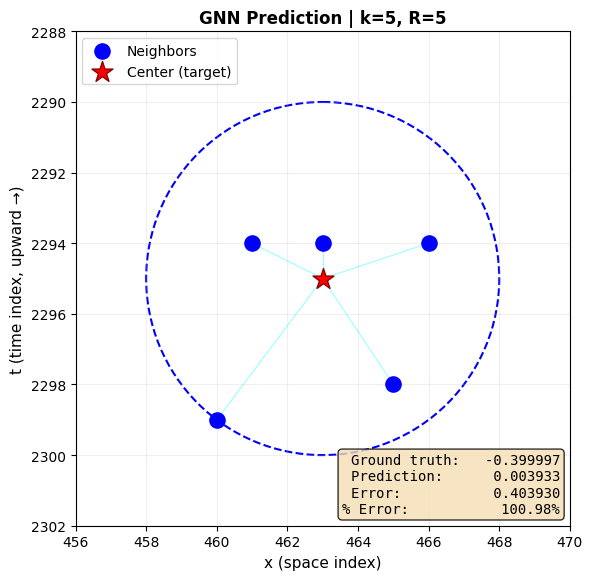

Error: 100.98%


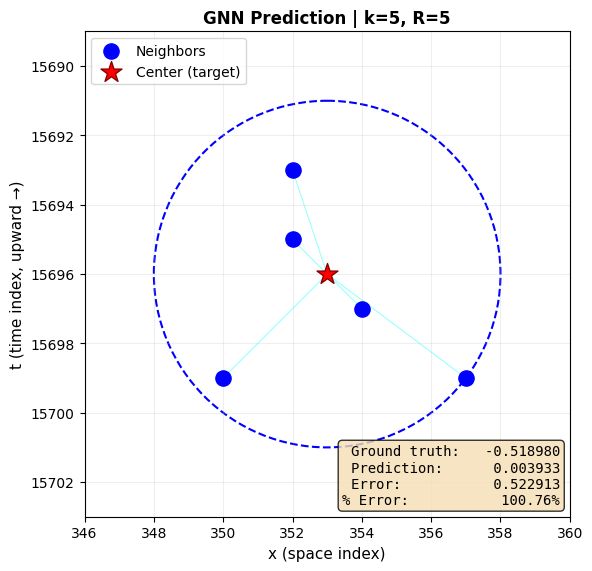

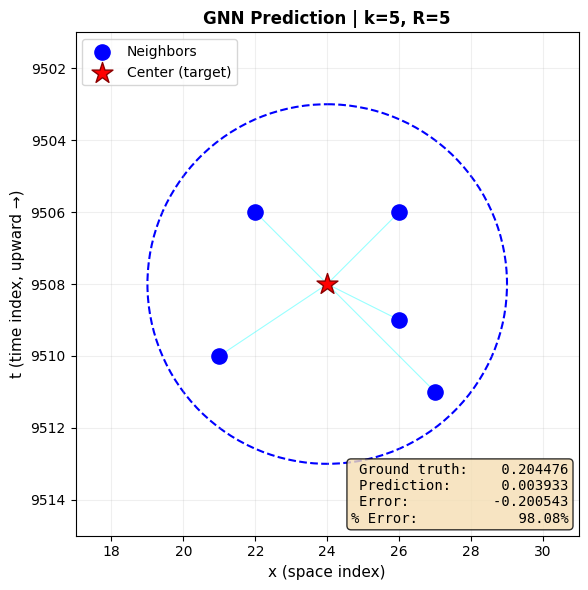

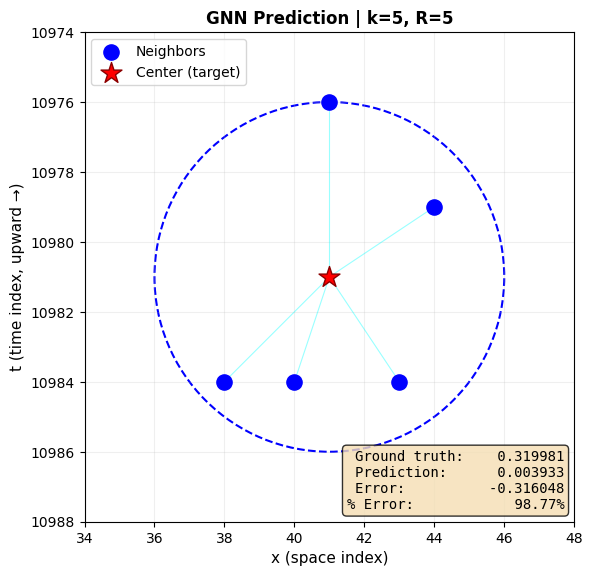

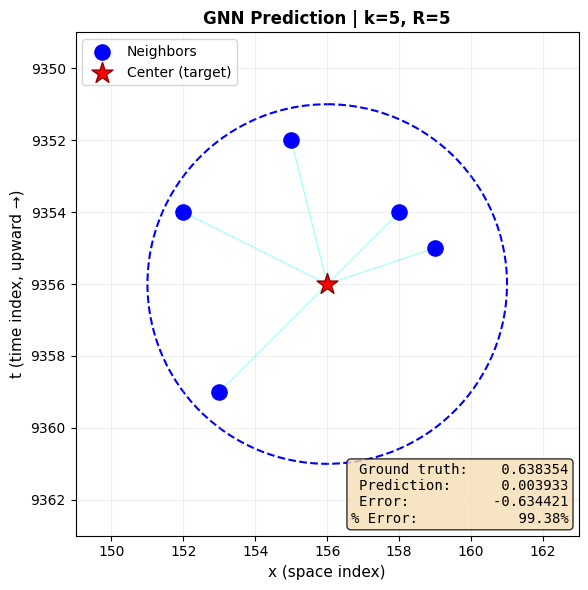

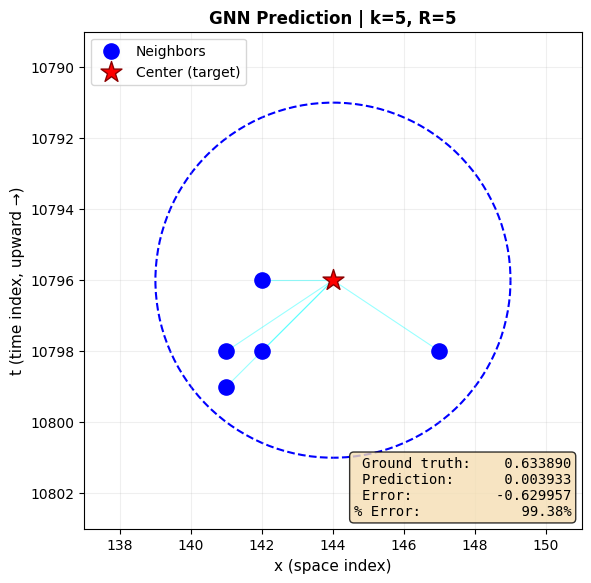

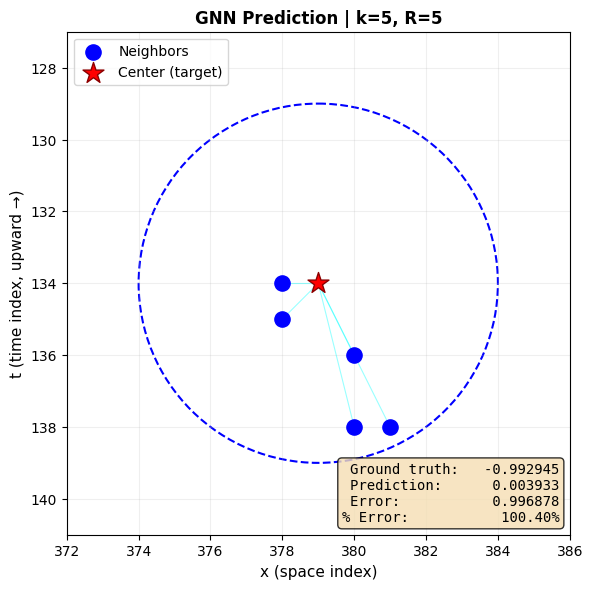

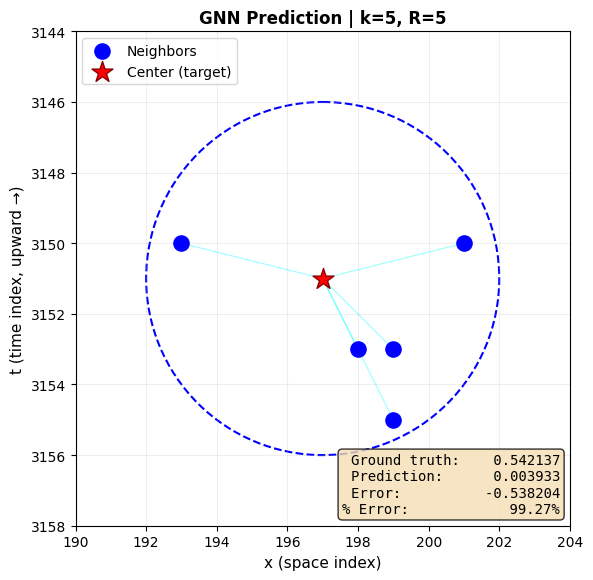

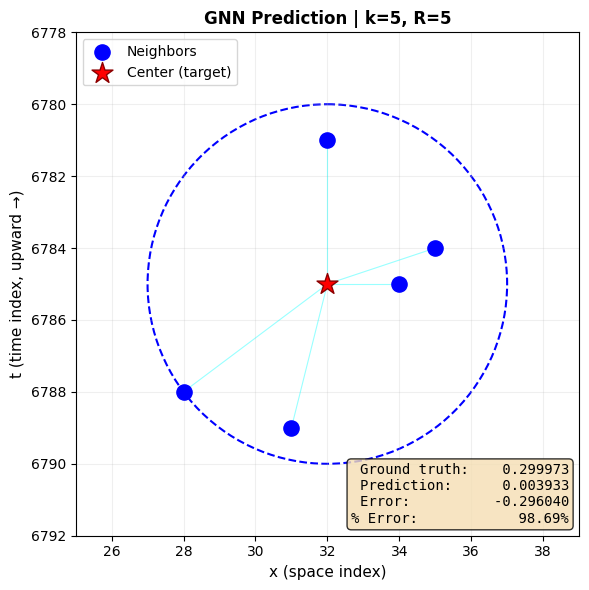

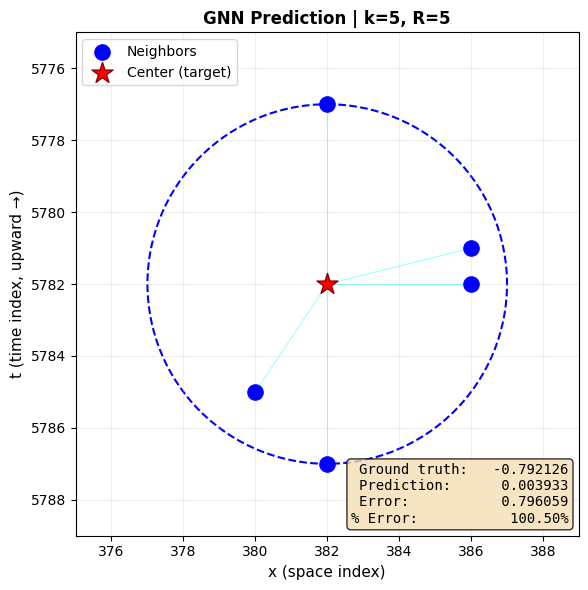

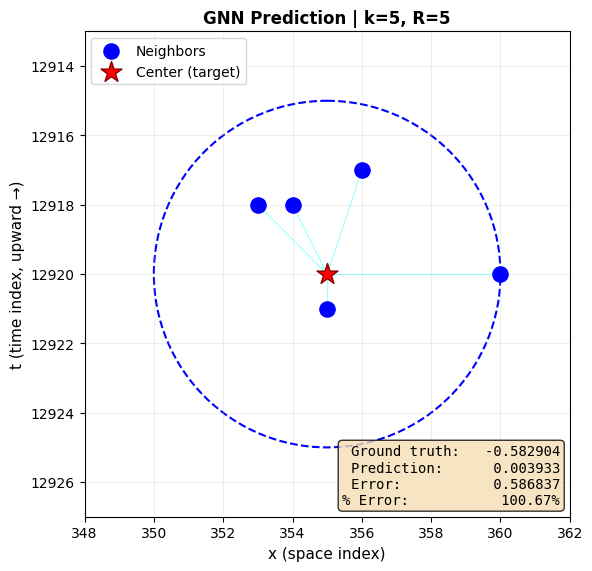

Mean error: 99.59%


In [30]:
# Quick test
result = visualize_B_with_prediction_gnn(data, model, R=5, k=5)
print(f"Error: {result['percent_error']:.2f}%")

# Multiple tests
errors = []
for _ in range(10):
    result = visualize_B_with_prediction_gnn(data, model, R=5, k=5)
    errors.append(result['percent_error'])
print(f"Mean error: {np.mean(errors):.2f}%")